# Model Building
---
## Feature Selection (FS)

In [965]:
import pandas as pd
df=pd.read_csv("Automobile_data.csv")

In [966]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [967]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [968]:
df.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [969]:
df.nunique()

symboling              6
normalized-losses     52
make                  22
fuel-type              2
aspiration             2
num-of-doors           3
body-style             5
drive-wheels           3
engine-location        2
wheel-base            53
length                75
width                 44
height                49
curb-weight          171
engine-type            7
num-of-cylinders       7
engine-size           44
fuel-system            8
bore                  39
stroke                37
compression-ratio     32
horsepower            60
peak-rpm              24
city-mpg              29
highway-mpg           30
price                187
dtype: int64

---
## Preprocessing + Class

In [970]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

In [971]:
class DataPreprocessing:
    def __init__(self, df):
        self.df=df.copy()
    def toldir(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype=='object':
                    self.df[col]=self.df[col].fillna(self.df[col].mode()[0])
                else:
                    self.df[col]=self.df[col].fillna(self.df[col].mean())
        return self
    def encodla(self):
        encoder=LabelEncoder()
        for col in self.df.columns:
            if self.df[col].dtype=='str':
                if self.df[col].nunique()<5:
                    dummies=pd.get_dummies(self.df[col],prefix=col,dtype=int)
                    self.df=pd.concat([self.df.drop(columns=[col]),dummies],axis=1)
                else:
                    self.df[col]=encoder.fit_transform(self.df[col])
        return self
    def scale(self):
        scaler=MinMaxScaler()
        for col in self.df.columns:
            num_col=self.df.select_dtypes(include=['int64','float64']).columns.drop('price')    
            self.df[num_col]=scaler.fit_transform(self.df[num_col])
        return self                

In [972]:
dp=DataPreprocessing(df)
dp.toldir().encodla().scale()
df=dp.df

In [973]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   symboling              205 non-null    float64
 1   normalized-losses      205 non-null    float64
 2   make                   205 non-null    float64
 3   body-style             205 non-null    float64
 4   wheel-base             205 non-null    float64
 5   length                 205 non-null    float64
 6   width                  205 non-null    float64
 7   height                 205 non-null    float64
 8   curb-weight            205 non-null    float64
 9   engine-type            205 non-null    float64
 10  num-of-cylinders       205 non-null    float64
 11  engine-size            205 non-null    float64
 12  fuel-system            205 non-null    float64
 13  bore                   205 non-null    float64
 14  stroke                 205 non-null    float64
 15  compression-ratio

In [974]:
df.head(10)

,symboling,normalized-losses,make,body-style,wheel-base,length,width,height,curb-weight,engine-type,...,aspiration_std,aspiration_turbo,num-of-doors_?,num-of-doors_four,num-of-doors_two,drive-wheels_4wd,drive-wheels_fwd,drive-wheels_rwd,engine-location_front,engine-location_rear
0,1.0,1.000000,0.000000,0.00,0.058309,0.413433,0.316667,0.083333,0.411171,0.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,1.0,1.000000,0.000000,0.00,0.058309,0.413433,0.316667,0.083333,0.411171,0.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,0.6,1.000000,0.000000,0.50,0.230321,0.449254,0.433333,0.383333,0.517843,0.833333,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,0.8,0.529412,0.047619,0.75,0.384840,0.529851,0.491667,0.541667,0.329325,0.500000,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.8,0.529412,0.047619,0.75,0.373178,0.529851,0.508333,0.541667,0.518231,0.500000,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
5,0.8,1.000000,0.047619,0.75,0.384840,0.540299,0.500000,0.441667,0.395268,0.500000,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6,0.6,0.490196,0.047619,0.75,0.559767,0.770149,0.925000,0.658333,0.525989,0.500000,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
7,0.6,1.000000,0.047619,1.00,0.559767,0.770149,0.925000,0.658333,0.568658,0.500000,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
8,0.6,0.490196,0.047619,0.75,0.559767,0.770149,0.925000,0.675000,0.619860,0.500000,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
9,0.4,1.000000,0.047619,0.50,0.376093,0.553731,0.633333,0.350000,0.607060,0.500000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


---
## Filter mathod -> train-test-splitdan oldin

In [975]:
import numpy as np

In [976]:
corr_matrix=df.corr().abs() # ...abs() - faqat musbat qiymatlar olish uchun
print(corr_matrix)

                       symboling  normalized-losses      make  body-style  \
symboling               1.000000           0.050579  0.118794    0.596135   
normalized-losses       0.050579           1.000000  0.089937    0.051574   
make                    0.118794           0.089937  1.000000    0.089494   
body-style              0.596135           0.051574  0.089494    1.000000   
wheel-base              0.531954           0.278059  0.078505    0.401362   
length                  0.357612           0.284522  0.119584    0.334433   
width                   0.232919           0.290199  0.003783    0.131710   
height                  0.541038           0.095379  0.236233    0.568534   
curb-weight             0.227691           0.371142  0.024015    0.128467   
engine-type             0.050372           0.060685  0.051538    0.037024   
num-of-cylinders        0.197762           0.063931  0.039937    0.048408   
engine-size             0.105790           0.330972  0.070918    0.073352   

In [977]:
upper=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
# High correlated qismini olish uchun ishlatilinadi
# corr_matrix.shape -> matritsaning o'lchamini oladi (5,5) -> ya'ni 5qator,5ustun)
# np.ones(...) -> huddi shu o'lchamdagi faqat 1 lardan iborat matritsa yaratadi
# np.triu(..., k=1) -> triu = triangle upper (yuqori uchburchak)
# k=1 -> diagonalni ham olib tashlaydi (faqat diagonalning ustidagi qiymatlar qoladi)
# .astype(bool) -> 0 va 1 ni False va True ga aylantiradi
# corr_matrix.where(...) -> True bo'lgan joydagi qiymatlarni qoldiradi, False bo'lgan joylarni NaN qiladi

In [978]:
to_drop=[col for col in upper.columns if any(upper[col] > 0.8)]
# upper.columns -> upper dagi barcha ustun nomlarini oladi
# for col in upper.columns -> har bir ustunni bittadan olib tekshiradi
# upper[col] -> tanlangan ustunning barcha qiymatlarini oladi
# upper[col] > 0.8 -> qiymatlar 0.8 dan kattami tekshiradi
# any(...) -> agar kamida bitta True bo'lsa, True qaytaradi (any([True, False, False]) -> natija: True)
print(to_drop)

['length', 'width', 'curb-weight', 'engine-size', 'highway-mpg', 'fuel-type_diesel', 'fuel-type_gas', 'aspiration_turbo', 'num-of-doors_two', 'drive-wheels_rwd', 'engine-location_rear']


In [979]:
df_filtered = df.drop(columns=to_drop)
print("\nOrginal shape:", df.shape)
print(f"Shape after dropping correlated features: {df_filtered.shape}")


Orginal shape: (205, 33)
Shape after dropping correlated features: (205, 22)


In [980]:
# More analysis
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix=df.corr().abs()

upper=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))

In [981]:
high_corr_pairs = []
for col in upper.columns:
    for row in upper.index: # .index -> rowlarni alohida ajratish uchun
        if upper.loc[row,col] is not np.nan and upper.loc[row,col] > 0.8:
        # if upper.loc[row,col] -> row qator va col ustun kesishgan joydagi qiymatni oladi
            high_corr_pairs.append([row,col,round(upper.loc[row,col],2)])
            # high_corr_pairs.append(...) -> topilgan juftlikni ro'yxatga qo'shadi
            # [row, col, round(upper.loc[row,col],2)] -> natija: ['row name', 'col name', 0.91]

In [982]:
corr_table = pd.DataFrame(high_corr_pairs, columns=['Feature1','Feature2','Correlation'])
print("Highly correlated feature pairs(correlation>0.8):")
print(corr_table)

Highly correlated feature pairs(correlation>0.8):
                 Feature1              Feature2  Correlation
0              wheel-base                length         0.87
1                  length                 width         0.84
2                  length           curb-weight         0.88
3                   width           curb-weight         0.87
4             curb-weight           engine-size         0.85
5                city-mpg           highway-mpg         0.97
6       compression-ratio      fuel-type_diesel         0.98
7       compression-ratio         fuel-type_gas         0.98
8        fuel-type_diesel         fuel-type_gas         1.00
9          aspiration_std      aspiration_turbo         1.00
10      num-of-doors_four      num-of-doors_two         0.98
11       drive-wheels_fwd      drive-wheels_rwd         0.91
12  engine-location_front  engine-location_rear         1.00


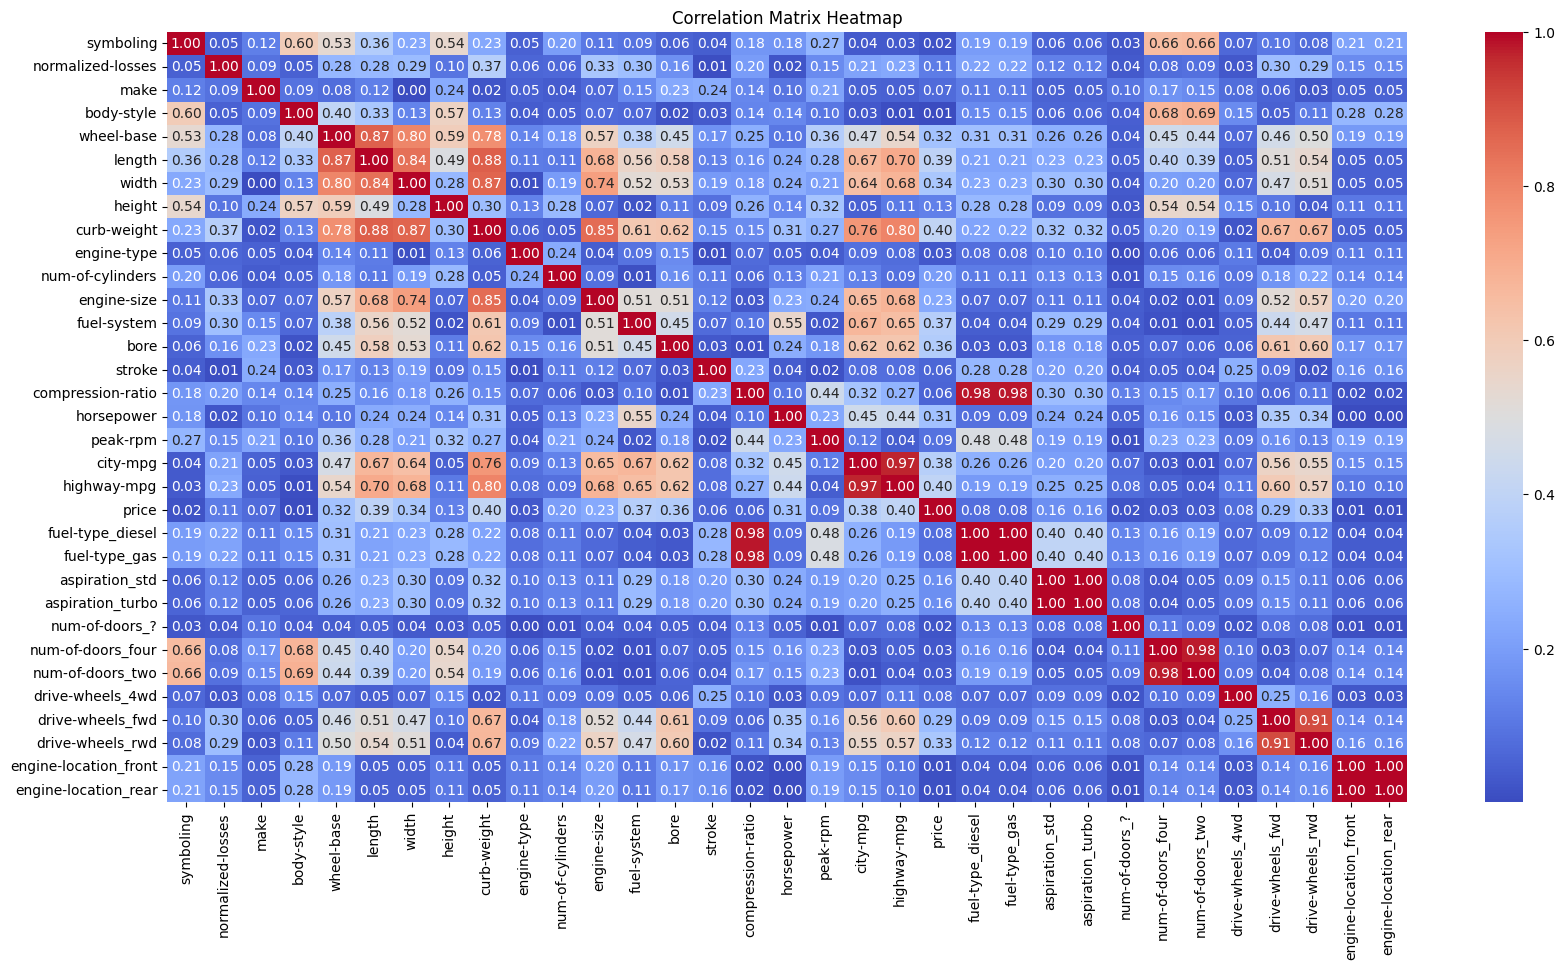

In [983]:
# Vizual ko'rinish
plt.figure(figsize=(20,10))
sns.heatmap(            # sns.heatmap(...) -> ma'lumotlarni ranglar orqali ko'rsatadi
    corr_matrix,        # chizilishi kerak bo'lgan ma'lumol nomi
    annot=True,         # annot=True -> har bir katakka son qiymatini yozib beradi
    fmt=".2f",      
    cmap="coolwarm",    # cmap="coolwarm" -> rang sxemasi(kuchli musbat korrelyatsiya → qizil, kuchli manfiy korrelyatsiya → ko'k, 0 ga yaqin → oq yoki och rang)
    cbar=True           # cbar=True -> O'ng tomonda ranglar shkalasini chiqaradi
)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [984]:
# Plotly Express
import plotly.express as px

    # Create a long-form dataframe for Plotly
corr_long = corr_matrix.reset_index().melt(id_vars='index')
# Bu qator korrelyatsiya matritsasini keng formatdan (wide format) uzun formatga (long format) o‘zgartiradi
# .reset_index() -> indexni oddiy ustunga aylantiradi
# .melt(id_vars='index') -> barcha ustunlarni bitta ustunga yig'adi
corr_long.columns = ['Feature1','Feature2','Correlation']
print(corr_long)

                   Feature1              Feature2  Correlation
0                 symboling             symboling     1.000000
1         normalized-losses             symboling     0.050579
2                      make             symboling     0.118794
3                body-style             symboling     0.596135
4                wheel-base             symboling     0.531954
...                     ...                   ...          ...
1084       drive-wheels_4wd  engine-location_rear     0.026114
1085       drive-wheels_fwd  engine-location_rear     0.144799
1086       drive-wheels_rwd  engine-location_rear     0.158772
1087  engine-location_front  engine-location_rear     1.000000
1088   engine-location_rear  engine-location_rear     1.000000

[1089 rows x 3 columns]


In [985]:
    # Inteactive heatmap with Plotly Express
fig = px.imshow(        # px.imshow(...) -> matritsani rangli heatmap sifatida chizadi (bu Plotly ning interaktiv versiyasi)
    corr_matrix,
    text_auto=".2f",    # text_auto=".2f" -> katak ichida qiymatlarni ko'rsatadi
    aspect="auto",      # aspect="auto" -> grafik o'lchamini avtomatik moslaydi
    # (Agar ustunlar va qatorlar soni ko'p bo'lsa, kataklarni siqib yoki cho'zib joylashtiradi)
    color_continuous_scale="RdBu_r",
    # color_continuous_scale="RdBu_r" -> rang sxemasi (Musbat korrelyatsiya → qizil, manfiy korrelyatsiya → ko'k, 0 ga yaqin → oq)
    # _r = reversed (ranglar teskari qilingan)
    zmin=-1,            # zmin=-1 -> rang shkalasining eng kichik qiymati (correlation min qiymati)
    zmax=1,             # zmax=1  ->  rang shkalasining eng katta qiymati (correlation max qiymati)
    title="Correlation Matrix Heatmap(Interactive)" # interaktiv -> sichqoncha olib borganda qiymatlarni ko'rsatishi
)

In [986]:
fig.update_layout(
# fig.update_layout(...) -> grafikning o'lchami, sarlavhalari, foni va boshqa dizayn elementlarini o'zgartiradi
    width=900,              # width=900 -> grafikning kengligi 900 piksel bo'ladi       
    height=800,             # height=800 -> grafikning balandligi 800 piksel bo'ladi
    xaxis_title="Features",     
    yaxis_title="Features"
    )

fig.show()

In [987]:
# Filter method -> Low variance varianti
from sklearn.feature_selection import VarianceThreshold
    
    # Set threshold for variance (e.g., 0.01)
threshold = 0.01

    # Initialize VarianceThreshold
selector = VarianceThreshold(threshold=threshold)

# corr_matrix=df.corr().abs()
# upper=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
# to_drop=[col for col in upper.columns if any(upper[col] > 0.8)]
# df_filtered = df.drop(columns=to_drop)

    # Fit on the dataset
selector.fit(df_filtered)

,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.01


In [988]:
    # Feature with Low variance
low_variance_features = df_filtered.columns[~selector.get_support()]
    #
# Bu qator Variance Threshold orqali olib tashlangan ustunlarning nomlarini olish uchun ishlatiladi
# selector.get_support() -> VarianceThreshold saqlab qolgan ustunlarni True, olib tashlaganlarini False qilib qaytaradi
# ~selector.get_support() -> (~ — mantiqiy inkor (NOT))
# misol: ~array([ True, False, True, False]) 
#      -> array([False, True, False, True])
# df_filtered.columns[...] -> boolean mask yordamida ustunlarni tanlaydi

print("Features with low variance (to drop):", list(low_variance_features))

Features with low variance (to drop): ['num-of-doors_?']


In [989]:
    # Drop Low-variance features
df_low_variance_filtered = df_filtered.drop(columns=low_variance_features)
print("\nOrginal shape:", df_filtered.shape)
print("Shape after dropping low_variance features: ", df_low_variance_filtered.shape)


Orginal shape: (205, 22)
Shape after dropping low_variance features:  (205, 21)


---
## Embedded Method with train-test-split

In [990]:
# Embedded method for linear models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
X=df.drop('price',axis=1)
y=df['price']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [991]:
lasso=LassoCV(cv=5,random_state=42)
lasso

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [992]:
lasso.fit(X_train,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [993]:
importance = np.abs(lasso.coef_)

In [994]:
selected_features = X_train.columns[lasso.coef_ != 0]
print(selected_features)

Index(['make', 'length', 'fuel-system', 'bore', 'horsepower', 'peak-rpm',
       'aspiration_std', 'aspiration_turbo', 'drive-wheels_rwd'],
      dtype='str')


In [995]:
print(len(selected_features))
print(len(top_features))

9
9


In [996]:
    # faqat muhim featurelarni saqlab qolish uchun
percentile_threshold = np.percentile(importance, 25) # top 75% feature
top_features = X_train.columns[importance>percentile_threshold]
print("\nTop 75% important features based on Lasso coefficient:")
print(top_features.tolist())


Top 75% important features based on Lasso coefficient:
['make', 'length', 'fuel-system', 'bore', 'horsepower', 'peak-rpm', 'aspiration_std', 'aspiration_turbo', 'drive-wheels_rwd']


In [997]:
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

In [1008]:
lasso_final = LassoCV(cv=5,random_state=42)
lasso_final.fit(X_train_selected, y_train)

y_pred = lasso_final.predict(X_test_selected)

In [1009]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("r2:", r2)
print("mse:", mse)
print("mae:", mae)

r2: 0.2578262135344027
mse: 2490.9021171413547
mae: 42.71689112354964


---
## Traindan keyin Wrapper Methods

In [1000]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

X=df.drop("price",axis=1)
y=df['price']

In [1001]:
model = LinearRegression()
rfe = RFE(model, n_features_to_select=5)
# n_features_to_select=5 -> eng yaxshi 5 ta feature qoldir
# fe.support_ — RFE qaysi featurelarni tanlaganini ko'rsatadigan boolean (True/False) massiv

In [1002]:
rfe.fit(X,y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",5
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1003]:
selected_features=X.columns[rfe.support_]
print("Selected features:",selected_features)

Selected features: Index(['curb-weight', 'num-of-cylinders', 'engine-size', 'city-mpg',
       'highway-mpg'],
      dtype='str')


In [1004]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

final_model.fit(X_train_selected, y_train)

y_pred = final_model.predict(X_test_selected)

In [1005]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("r2: ", r2)
print("mse: ", mse)
print("mae: ", mae)

r2:  0.2690272770924417
mse:  2453.308829100525
mae:  42.41637942834586
